In [1]:
# Import Libs
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random

from stable_baselines3 import PPO

import matplotlib.pyplot as plt

In [2]:
# Build Model
class TempCtrlEnv(gym.Env):
    """A very simple environment for Richard to learn RL using Gymnasium."""
    
    metadata = {"render_modes": ["human"]} # USed for the Renderer duing programing. Not really needed anymore.

    def __init__(self, render_mode=None):
        super().__init__()
        
        # Actions: 
        # |-> 0 = decrease
        # |-> 1 = hold (No Action)
        # |-> 2 = increase
        self.action_space = spaces.Discrete(3)
        
        # Observation: current temperature (1D)
        self.observation_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([100.0], dtype=np.float32),
            dtype=np.float32
        )
        
        self.target = 37.0   # ideal human temperature
        self.max_steps = 100
        self.render_mode = render_mode

        self.reset()
        


    
    def _random_temp(self, gap=5, spread=10):
        """Return a random temperature 'spread' units away from target!"""
        if random.random() < 0.5:
            return random.uniform(self.target - spread, self.target - gap)
        else:
            return random.uniform(self.target + gap, self.target + spread)
    
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.temp = self._random_temp() 
        self.step_count = 0
        obs = np.array([self.temp], dtype=np.float32)
        return obs, {}

    def step(self, action):
        self.step_count += 1

        # Random environmental temperature drift
        drift = random.choice([-0.5, 0, 0.5])
        self.temp += drift

        # Apply agent action
        if action == 0:   # decrease temp
            self.temp -= 1
        elif action == 2: # increase temp
            self.temp += 1
        # (action == 1) means do nothing

        # Clamp between 0 and 100
        self.temp = float(np.clip(self.temp, 0, 100))

        # Reward: higher when closer to target (negative absolute error)
        error = abs(self.target - self.temp)
        reward = -error / 5.0  # scale down for stability

        done = self.step_count >= self.max_steps
        truncated = False

        obs = np.array([self.temp], dtype=np.float32)
        info = {"error": error, "drift": drift}
        return obs, reward, done, truncated, info

    def render(self):
        print(f"Step {self.step_count:3d} | Temp: {self.temp:5.2f}")

    def close(self):
        pass


In [3]:
# Run 9 Simulatiosn and Plot the Results!
def run_simulation(model, n_runs=9, title="Temp. Ctrl Sim"):
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    total_rewards = []

    for i in range(n_runs):
        env = TempCtrlEnv()
        obs, _ = env.reset(seed=42)
        temps, rewards = [], []
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, _ = env.step(action)
            temps.append(obs[0])
            rewards.append(reward)
            
        total_reward = sum(rewards)
        total_rewards.append(total_reward)
        avg_reward = np.mean(rewards)

        ax = axes[i]
        ax.plot(temps, label=f"Run {i+1}")
        ax.axhline(37, color="r", linestyle="--", label="Target (37°C)")
        ax.axhline(36, color="gray", linestyle=":")
        ax.axhline(38, color="gray", linestyle=":")
        ax.set_title(f"Run {i+1} | Total Reward: {total_reward:.2f}\nAvg: {avg_reward:.3f}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Temperature")
        ax.legend()
        
    # Get Average total reward across all runs
    avg_total_reward = np.mean(total_rewards)

    # Large Title
    fig.suptitle(
        f"\n*\n*\n*\n\n{title}\nAverage Total Reward: {avg_total_reward:.2f}",
        fontsize=16, 
        fontweight="bold", 
        y=1.05)
    
    plt.tight_layout()
    plt.show()

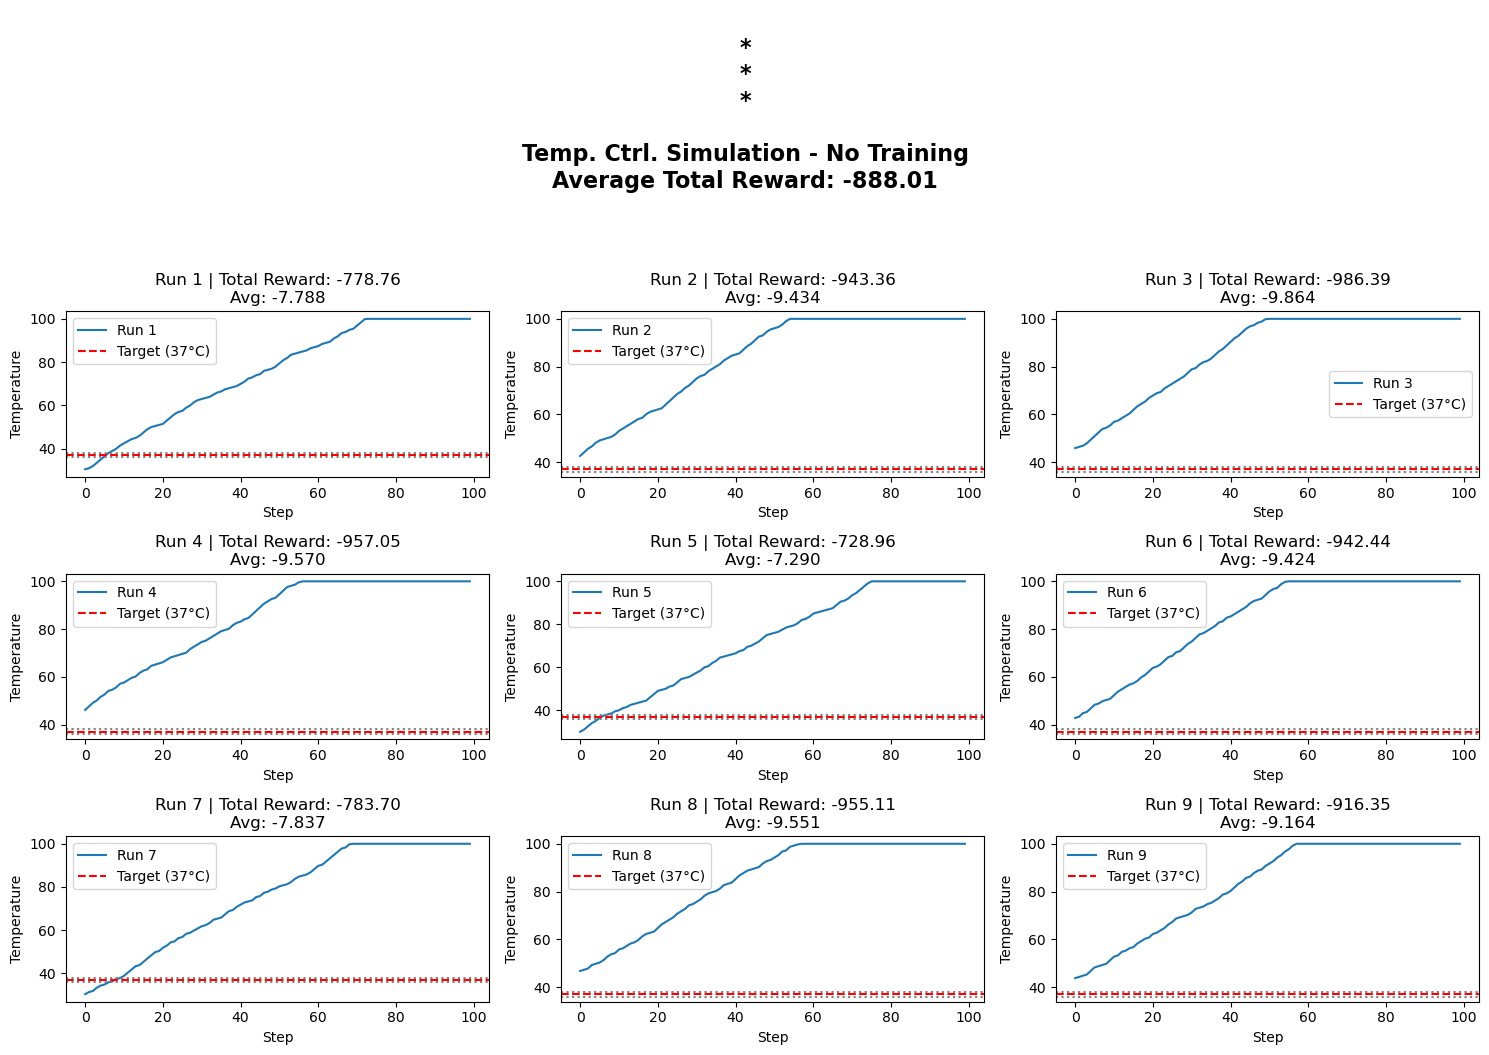

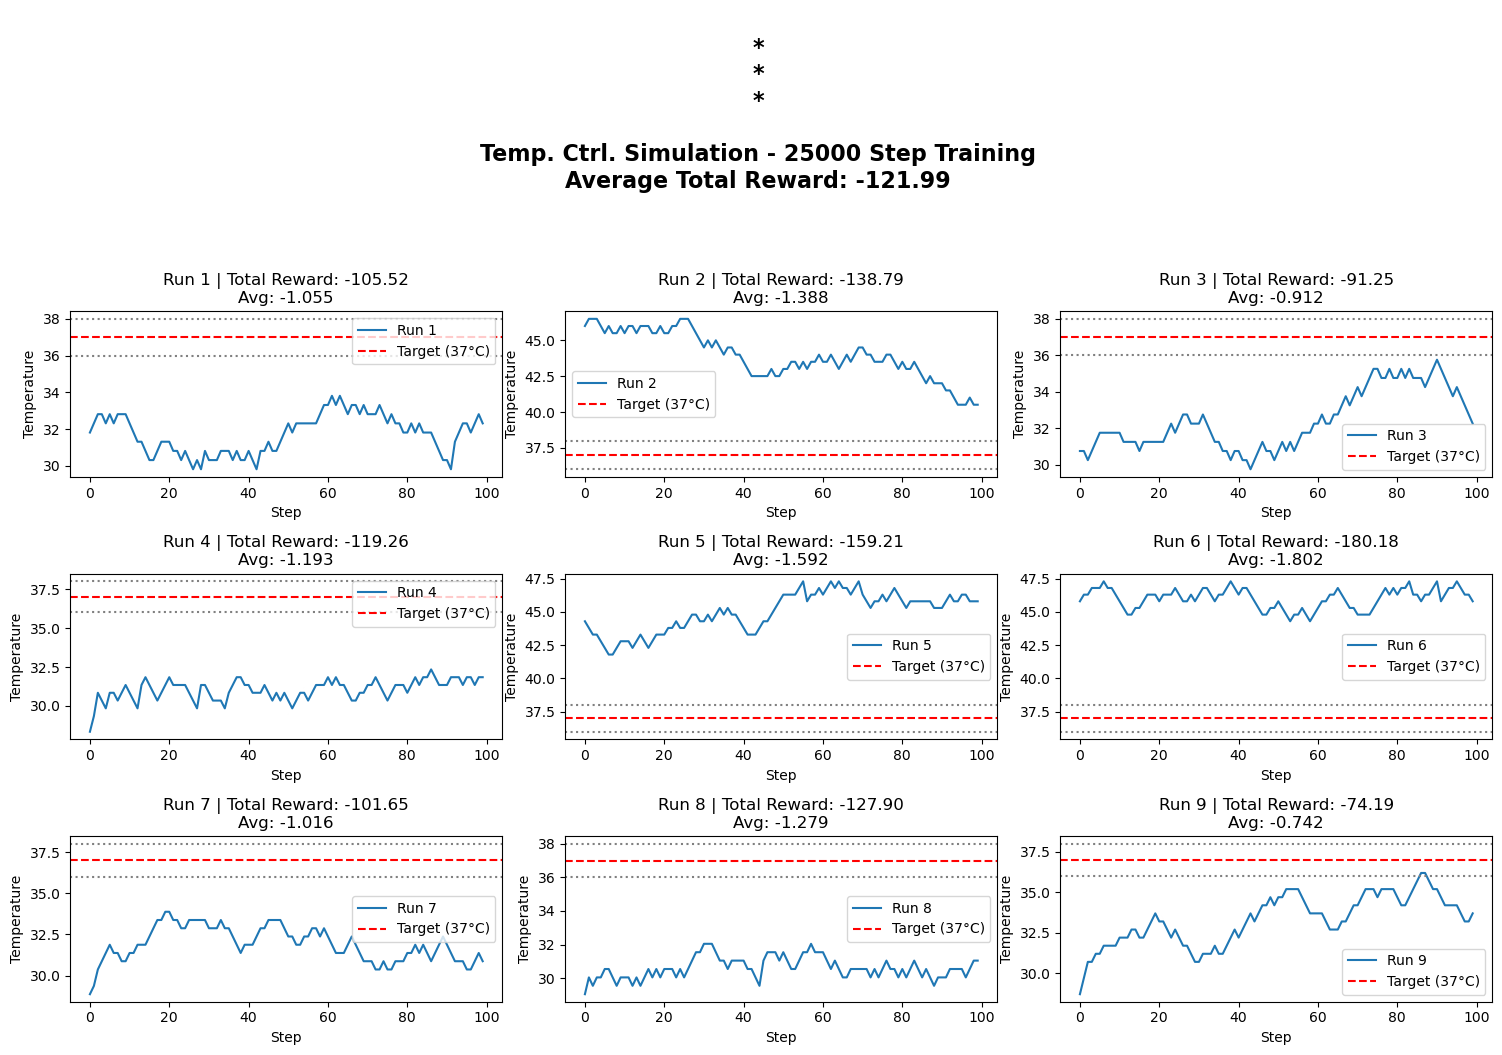

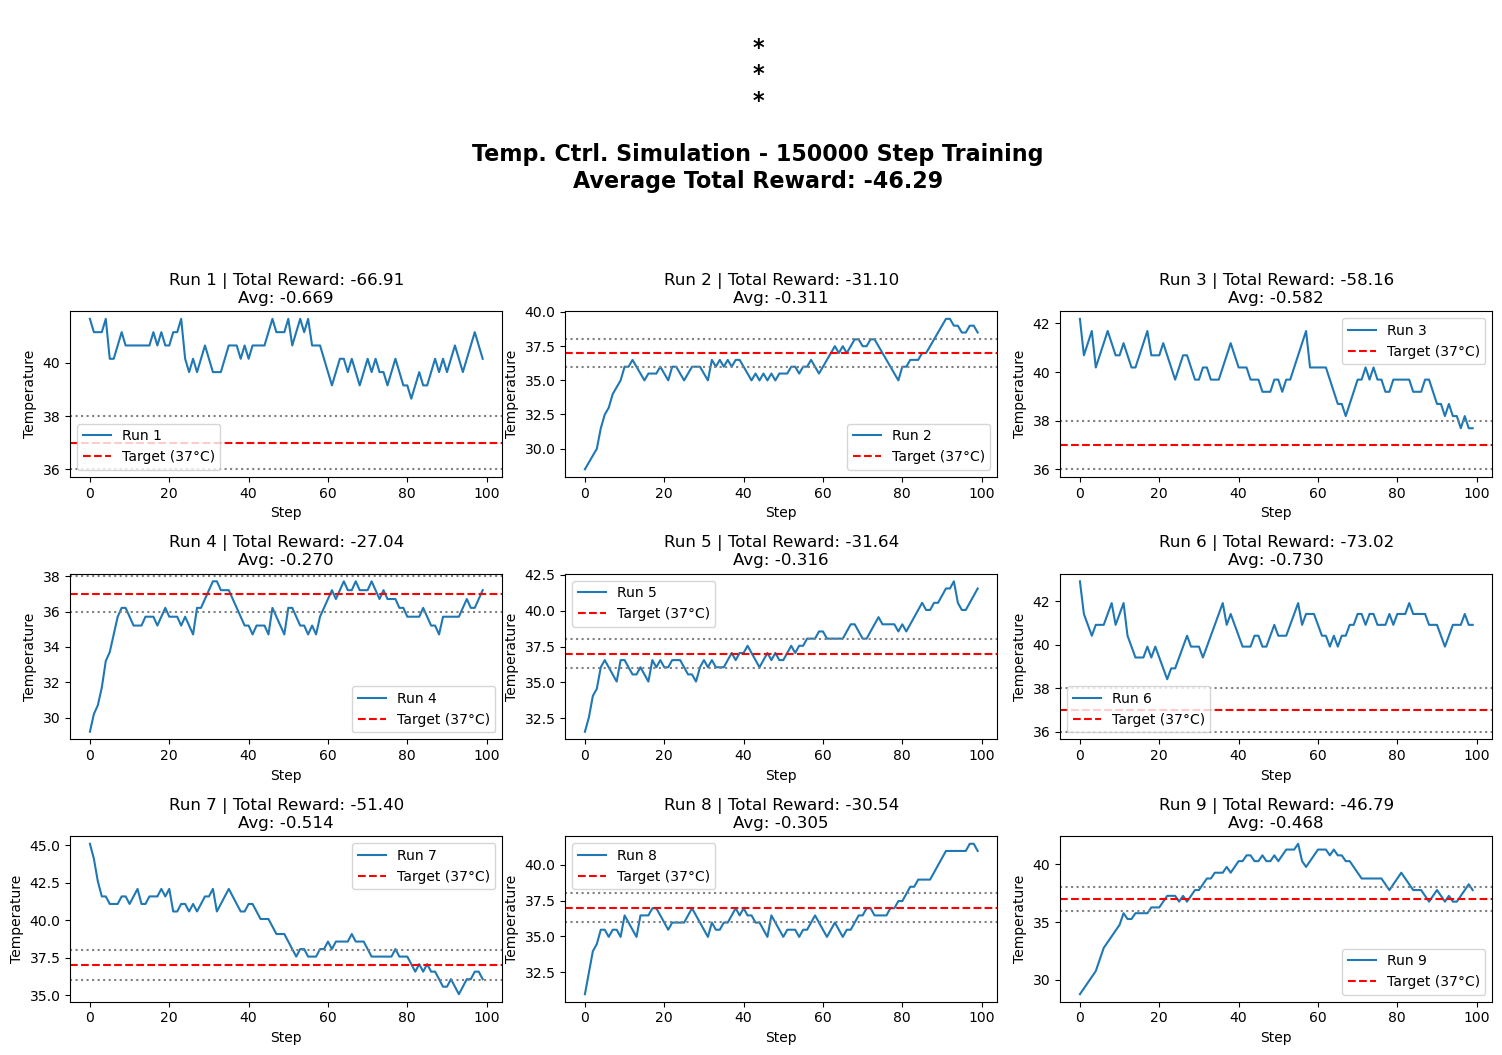

In [4]:
# Instantiate Model


# Show: No Traing Done!
model_A = PPO("MlpPolicy", TempCtrlEnv(), verbose=0)
run_simulation(model_A, title="Temp. Ctrl. Simulation - No Training")

# Show: 25,000 Step Traing Done!
STEP_COUNT = 25_000
model_B = PPO("MlpPolicy", TempCtrlEnv(), verbose=0)
model_B.learn(total_timesteps=STEP_COUNT)
run_simulation(model_B, title=f"Temp. Ctrl. Simulation - {STEP_COUNT} Step Training")

# Show: 150,000 Step Traing Done!
STEP_COUNT = 150_000
model_C = PPO("MlpPolicy", TempCtrlEnv(), verbose=0)
model_C.learn(total_timesteps=STEP_COUNT)
run_simulation(model_C, title=f"Temp. Ctrl. Simulation - {STEP_COUNT} Step Training")
